# Quick Error Model Test

Minimal test: for each dataset (Microsoft, Chandak, Noisy DNA), compare
finetuned vs pretrained on:
1. **Real** test data
2. **Error model** synthetic data (histogram sampling, with bursts)
3. **Plain IDS** synthetic data (pretraining-style, no error model)
4. **DNAFormer error model** synthetic data (Microsoft only)

20 experiments total. If error model is good: finetuned > pretrained on error model data.

In [ ]:
%matplotlib inline
import os, sys, gc, random, pickle
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict
from huggingface_hub import hf_hub_download

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.gpt_pkg.model import GPT, GPTConfig
from src.eval_pkg.GPT_Inference import GPT_Inference
from src.utils.helper_functions import filter_string
from src.utils.hamming_distance import hamming_distance_postprocessed
from Levenshtein import distance as levenshtein_distance
from tutorial.utils import get_model_info, load_vocabulary

stoi, itos = load_vocabulary()
decode = lambda t: ''.join(itos[i] for i in t)
encode_str = lambda s: [stoi.get(ch, stoi.get('<unk>', 0)) for ch in s]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ctx = torch.amp.autocast('cuda', dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16)

SEED = 42
results_dir = Path('results')
results_dir.mkdir(exist_ok=True)
synth_dir = Path('synthetic_error_model_data')
synth_dir.mkdir(exist_ok=True)

print(f'Device: {device}')

## 1. Generate synthetic test data

In [2]:
from src.data_pkg.data_generation import load_error_model, data_generation_with_error_model
from src.data_pkg.IDS_channel import IDS_channel

# Dataset configs: error model path, seq length, n_examples, overall error rates for plain IDS
DATASETS = {
    'microsoft': {
        'error_model_path': '../data/error_model/results_microsoft/error_model.json',
        'seq_length': 110,
        'n_examples': 5109,
        'sub_prob': 0.0168, 'del_prob': 0.0218, 'ins_prob': 0.0190,
        'real_reads': '../data/microsoft_data/data_microsoft/reads.txt',
        'real_gt': '../data/microsoft_data/data_microsoft/ground_truth.txt',
        'finetuned': {'model_seq_length': 110, 'model_variant': 'microsoft'},
        'pretrained': {'model_seq_length': 110, 'model_variant': 'pretrained'},
    },
    'chandak': {
        'error_model_path': '../data/error_model/results_chandak/error_model.json',
        'seq_length': 117,
        'n_examples': 8481,
        'sub_prob': 0.0345, 'del_prob': 0.0422, 'ins_prob': 0.0587,
        'real_reads': '../data/chandak/data_chandak/reads.txt',
        'real_gt': '../data/chandak/data_chandak/ground_truth.txt',
        'finetuned': {'model_seq_length': 117, 'model_variant': 'chandak'},
        'pretrained': {'model_seq_length': 'var_50_120', 'model_variant': 'pretrained'},
    },
    'noisy_dna': {
        'error_model_path': '../data/error_model/results_noisy/error_model.json',
        'seq_length': 60,
        'n_examples': 15696,
        'sub_prob': 0.0245, 'del_prob': 0.0296, 'ins_prob': 0.1192,
        'real_reads': '../data/noisy_dna/noisy_dna_data_storage/data/splits/reads.txt',
        'real_gt': '../data/noisy_dna/noisy_dna_data_storage/data/splits/ground_truth.txt',
        'finetuned': {'model_seq_length': 60, 'model_variant': 'noisy_dna'},
        'pretrained': {'model_seq_length': 60, 'model_variant': 'pretrained'},
    },
}

def save_synthetic(clusters, ground_truths, out_dir):
    out_dir.mkdir(exist_ok=True)
    with open(out_dir / 'reads.txt', 'w') as f:
        for j, cluster in enumerate(clusters):
            for read in cluster:
                f.write(read + '\n')
            if j < len(clusters) - 1:
                f.write('===============================\n')
    with open(out_dir / 'ground_truth.txt', 'w') as f:
        for gt in ground_truths:
            f.write(gt + '\n')

for ds_name, ds in DATASETS.items():
    # --- Error model synthetic (histogram) ---
    em_dir = synth_dir / f'{ds_name}_errmodel_histogram'
    if (em_dir / 'reads.txt').exists():
        print(f'{ds_name} error model (histogram): CACHED')
    else:
        print(f'Generating {ds_name} error model (histogram)...')
        error_model = load_error_model(ds['error_model_path'])
        rng = random.Random(SEED)
        clusters, gts = [], []
        for _ in tqdm(range(ds['n_examples']), desc=f'  {ds_name} errmodel'):
            obs_size = rng.randint(2, 10)
            pairs = data_generation_with_error_model(
                error_model=error_model, observation_size=obs_size,
                length_ground_truth=ds['seq_length'], target_type='CPRED',
                rng=rng, error_rate_sampling='histogram')
            gt = pairs[0][1][0]
            reads = pairs[1][1][0].split(':')[0].split('|')
            clusters.append(reads); gts.append(gt)
        save_synthetic(clusters, gts, em_dir)
        print(f'  Saved {len(clusters)} examples')

    # --- Plain IDS synthetic ---
    ids_dir = synth_dir / f'{ds_name}_plain_ids'
    if (ids_dir / 'reads.txt').exists():
        print(f'{ds_name} plain IDS: CACHED')
    else:
        print(f'Generating {ds_name} plain IDS...')
        rng = random.Random(SEED)
        channel_stats = {
            'substitution_probability': ds['sub_prob'],
            'deletion_probability': ds['del_prob'],
            'insertion_probability': ds['ins_prob'],
        }
        alphabet = ['A', 'C', 'G', 'T']
        clusters, gts = [], []
        for _ in tqdm(range(ds['n_examples']), desc=f'  {ds_name} plain IDS'):
            obs_size = rng.randint(2, 10)
            gt = ''.join(rng.choice(alphabet) for _ in range(ds['seq_length']))
            reads = [IDS_channel(gt, channel_stats, rng) for _ in range(obs_size)]
            clusters.append(reads); gts.append(gt)
        save_synthetic(clusters, gts, ids_dir)
        print(f'  Saved {len(clusters)} examples')

print('\nDone generating all synthetic data.')

# --- DNAFormer error model synthetic (Microsoft only) ---
dnaformer_dir = synth_dir / 'microsoft_dnaformer'
if (dnaformer_dir / 'reads.txt').exists():
    print('microsoft DNAFormer error model: CACHED')
else:
    print('Generating microsoft DNAFormer error model...')
    sys.path.insert(0, str(project_root / 'data' / 'error_model'))
    from data.error_model.generate_dnaformer_synthetic import generate as generate_dnaformer
    generate_dnaformer(
        dataset='microsoft',
        num_clusters=5109,
        output_dir=str(dnaformer_dir),
        gt_length=110,
        delta=0.5,
        seed=SEED,
    )
    print('  Done.')

microsoft error model (histogram): CACHED
microsoft plain IDS: CACHED
chandak error model (histogram): CACHED
chandak plain IDS: CACHED
noisy_dna error model (histogram): CACHED
noisy_dna plain IDS: CACHED

Done generating all synthetic data.
microsoft DNAFormer error model: CACHED


## 2. Define experiments

In [3]:
experiments = []

for ds_name, ds in DATASETS.items():
    label = ds_name.replace('_', ' ').title()
    sl = ds['seq_length']
    ft = ds['finetuned']
    pt = ds['pretrained']

    # Real data
    experiments.append({
        'name': f'{label} finetuned on real',
        'dataset': ds_name, 'data_type': 'real',
        'reads_path': ds['real_reads'], 'gt_path': ds['real_gt'],
        'seq_length': sl, **ft,
    })
    experiments.append({
        'name': f'{label} pretrained on real',
        'dataset': ds_name, 'data_type': 'real',
        'reads_path': ds['real_reads'], 'gt_path': ds['real_gt'],
        'seq_length': sl, **pt,
    })

    # Error model synthetic (histogram)
    experiments.append({
        'name': f'{label} finetuned on errmodel',
        'dataset': ds_name, 'data_type': 'errmodel',
        'reads_path': f'synthetic_error_model_data/{ds_name}_errmodel_histogram/reads.txt',
        'gt_path': f'synthetic_error_model_data/{ds_name}_errmodel_histogram/ground_truth.txt',
        'seq_length': sl, **ft,
    })
    experiments.append({
        'name': f'{label} pretrained on errmodel',
        'dataset': ds_name, 'data_type': 'errmodel',
        'reads_path': f'synthetic_error_model_data/{ds_name}_errmodel_histogram/reads.txt',
        'gt_path': f'synthetic_error_model_data/{ds_name}_errmodel_histogram/ground_truth.txt',
        'seq_length': sl, **pt,
    })

    # Plain IDS synthetic
    experiments.append({
        'name': f'{label} finetuned on plainIDS',
        'dataset': ds_name, 'data_type': 'plain_ids',
        'reads_path': f'synthetic_error_model_data/{ds_name}_plain_ids/reads.txt',
        'gt_path': f'synthetic_error_model_data/{ds_name}_plain_ids/ground_truth.txt',
        'seq_length': sl, **ft,
    })
    experiments.append({
        'name': f'{label} pretrained on plainIDS',
        'dataset': ds_name, 'data_type': 'plain_ids',
        'reads_path': f'synthetic_error_model_data/{ds_name}_plain_ids/reads.txt',
        'gt_path': f'synthetic_error_model_data/{ds_name}_plain_ids/ground_truth.txt',
        'seq_length': sl, **pt,
    })

print(f'{len(experiments)} experiments:')
for exp in experiments:
    print(f"  {exp['name']}")

# DNAFormer error model (Microsoft only — no matching profile for Chandak/Noisy DNA)
experiments.append({
    'name': 'Microsoft finetuned on DNAFormer errmodel',
    'dataset': 'microsoft', 'data_type': 'dnaformer_errmodel',
    'reads_path': 'synthetic_error_model_data/microsoft_dnaformer/reads.txt',
    'gt_path': 'synthetic_error_model_data/microsoft_dnaformer/ground_truth.txt',
    'seq_length': 110, 'model_seq_length': 110, 'model_variant': 'microsoft',
})
experiments.append({
    'name': 'Microsoft pretrained on DNAFormer errmodel',
    'dataset': 'microsoft', 'data_type': 'dnaformer_errmodel',
    'reads_path': 'synthetic_error_model_data/microsoft_dnaformer/reads.txt',
    'gt_path': 'synthetic_error_model_data/microsoft_dnaformer/ground_truth.txt',
    'seq_length': 110, 'model_seq_length': 110, 'model_variant': 'pretrained',
})

print(f'\n{len(experiments)} experiments total:')
for exp in experiments:
    print(f"  {exp['name']}")

18 experiments:
  Microsoft finetuned on real
  Microsoft pretrained on real
  Microsoft finetuned on errmodel
  Microsoft pretrained on errmodel
  Microsoft finetuned on plainIDS
  Microsoft pretrained on plainIDS
  Chandak finetuned on real
  Chandak pretrained on real
  Chandak finetuned on errmodel
  Chandak pretrained on errmodel
  Chandak finetuned on plainIDS
  Chandak pretrained on plainIDS
  Noisy Dna finetuned on real
  Noisy Dna pretrained on real
  Noisy Dna finetuned on errmodel
  Noisy Dna pretrained on errmodel
  Noisy Dna finetuned on plainIDS
  Noisy Dna pretrained on plainIDS

20 experiments total:
  Microsoft finetuned on real
  Microsoft pretrained on real
  Microsoft finetuned on errmodel
  Microsoft pretrained on errmodel
  Microsoft finetuned on plainIDS
  Microsoft pretrained on plainIDS
  Chandak finetuned on real
  Chandak pretrained on real
  Chandak finetuned on errmodel
  Chandak pretrained on errmodel
  Chandak finetuned on plainIDS
  Chandak pretrained on

## 3. Run inference

In [4]:
# Load cached results
test_pkl = results_dir / 'test_error_model_results.pkl'
if test_pkl.exists():
    with open(test_pkl, 'rb') as f:
        all_results = pickle.load(f)
    print(f'Loaded {len(all_results)} cached experiments')
else:
    all_results = {}

for exp in experiments:
    if exp['name'] in all_results:
        print(f"CACHED: {exp['name']}")
        continue

    print(f"\n{'='*60}")
    print(f"Running: {exp['name']}")
    print(f"{'='*60}")

    # Load data
    with open(exp['reads_path'], 'r') as f:
        content = f.read()
    clusters = [c.strip().split('\n') for c in content.split('===============================') if c.strip()]
    valid_clusters = [c for c in clusters if 2 <= len(c) <= 10]

    with open(exp['gt_path'], 'r') as f:
        all_gts = [line.strip() for line in f if line.strip()]
    valid_indices = [i for i, c in enumerate(clusters) if 2 <= len(c) <= 10]
    gts = [all_gts[i] for i in valid_indices]

    exp_inputs = [f"{'|'.join(cluster)}:{gt}" for cluster, gt in zip(valid_clusters, gts)]

    # Load model
    model_info = get_model_info(exp['model_seq_length'], exp['model_variant'])
    print(f"  Model: {model_info['model_name']}")

    block_size = model_info['block_size']
    filtered = [(inp, gt) for inp, gt in zip(exp_inputs, gts)
                if len(inp.split(':')[0]) + 1 + exp['seq_length'] <= block_size]
    if len(filtered) < len(exp_inputs):
        print(f"  Skipped {len(exp_inputs) - len(filtered)} examples exceeding block_size")
    exp_inputs, gts = zip(*filtered) if filtered else ([], [])
    exp_inputs, gts = list(exp_inputs), list(gts)
    print(f"  {len(exp_inputs)} examples")

    model_path = hf_hub_download(
        repo_id=model_info['repo_id'], filename=model_info['model_name'], cache_dir='./models')
    ckpt = torch.load(model_path, map_location='cpu')
    config_args = {k: v for k, v in ckpt['model_args'].items() if k != 'model_type'}
    state_dict = {k.replace('_orig_mod.', ''): v for k, v in ckpt['model'].items()}
    exp_model = GPT(GPTConfig(**config_args))
    exp_model.load_state_dict(state_dict, strict=True)
    exp_model = exp_model.half().to(device).eval()

    inf_params = {
        'model': exp_model, 'ctx': ctx, 'device': device,
        'stoi': stoi, 'itos': itos, 'encode': encode_str, 'decode': decode,
        'temperature': 1.0, 'greedy': True,
        'ground_truth_length': exp['seq_length'],
        'block_size': block_size, 'target_type': 'CPRED',
        'constrained_generation': True,
    }

    examples_sorted = sorted(enumerate(zip(exp_inputs, gts)),
                             key=lambda x: len(x[1][0].split(':')[0]))

    batch_size = 200
    sorted_results = []
    with torch.inference_mode(), ctx:
        for start in tqdm(range(0, len(examples_sorted), batch_size), desc='  Inference'):
            batch = examples_sorted[start:start + batch_size]
            b_inputs = [x[1][0] for x in batch]
            b_gts = [x[1][1] for x in batch]
            b_cs = [len(inp.split(':')[0].split('|')) for inp in b_inputs]

            out = GPT_Inference(inf_params).inference(b_inputs, alignment_size=b_cs)
            preds = out['candidate_sequences']

            for (orig_idx, _), gt, pred, cs in zip(batch, b_gts, preds, b_cs):
                pred_f = filter_string(pred)[:len(gt)]
                sorted_results.append({
                    'original_index': orig_idx,
                    'cluster_size': cs,
                    'ground_truth': gt,
                    'prediction': pred_f,
                    'levenshtein': levenshtein_distance(gt, pred_f) / len(gt),
                })

    sorted_results.sort(key=lambda x: x['original_index'])
    exp_results = [{k: v for k, v in r.items() if k != 'original_index'} for r in sorted_results]
    all_results[exp['name']] = exp_results

    lev = [r['levenshtein'] for r in exp_results]
    print(f"  Mean Lev: {np.mean(lev):.4f}, Failure: {100*sum(l>0 for l in lev)/len(lev):.1f}%")

    # Save incrementally
    with open(test_pkl, 'wb') as f:
        pickle.dump(all_results, f)

    del exp_model, ckpt, state_dict
    gc.collect(); torch.cuda.empty_cache()

print('\nAll done!')

Loaded 12 cached experiments
CACHED: Microsoft finetuned on real
CACHED: Microsoft pretrained on real
CACHED: Microsoft finetuned on errmodel
CACHED: Microsoft pretrained on errmodel
CACHED: Microsoft finetuned on plainIDS
CACHED: Microsoft pretrained on plainIDS
CACHED: Chandak finetuned on real
CACHED: Chandak pretrained on real
CACHED: Chandak finetuned on errmodel
CACHED: Chandak pretrained on errmodel
CACHED: Chandak finetuned on plainIDS
CACHED: Chandak pretrained on plainIDS

Running: Noisy Dna finetuned on real
  Model: finetuned_noisy_dna_len60.pt
  15696 examples
FlashAttention available (will be used during training and inference with KV cache)


  Inference: 100%|██████████| 79/79 [01:14<00:00,  1.06it/s]


  Mean Lev: 0.2353, Failure: 83.0%

Running: Noisy Dna pretrained on real
  Model: model_seq_len_60.pt
  15696 examples


  Inference: 100%|██████████| 79/79 [01:14<00:00,  1.06it/s]


  Mean Lev: 0.3421, Failure: 100.0%

Running: Noisy Dna finetuned on errmodel
  Model: finetuned_noisy_dna_len60.pt
  15696 examples


...

  Mean Lev: 0.0235, Failure: 35.4%

Running: Microsoft finetuned on DNAFormer errmodel
  Model: finetuned_microsoft_dna_len110.pt
  4569 examples


  Inference: 100%|██████████| 23/23 [01:02<00:00,  2.71s/it]


  Mean Lev: 0.0089, Failure: 28.7%

Running: Microsoft pretrained on DNAFormer errmodel
  Model: model_seq_len_110.pt
  4569 examples


  Inference: 100%|██████████| 23/23 [01:02<00:00,  2.73s/it]


  Mean Lev: 0.0051, Failure: 15.1%

All done!


## 4. Plot

Saved to results/test_error_model.png


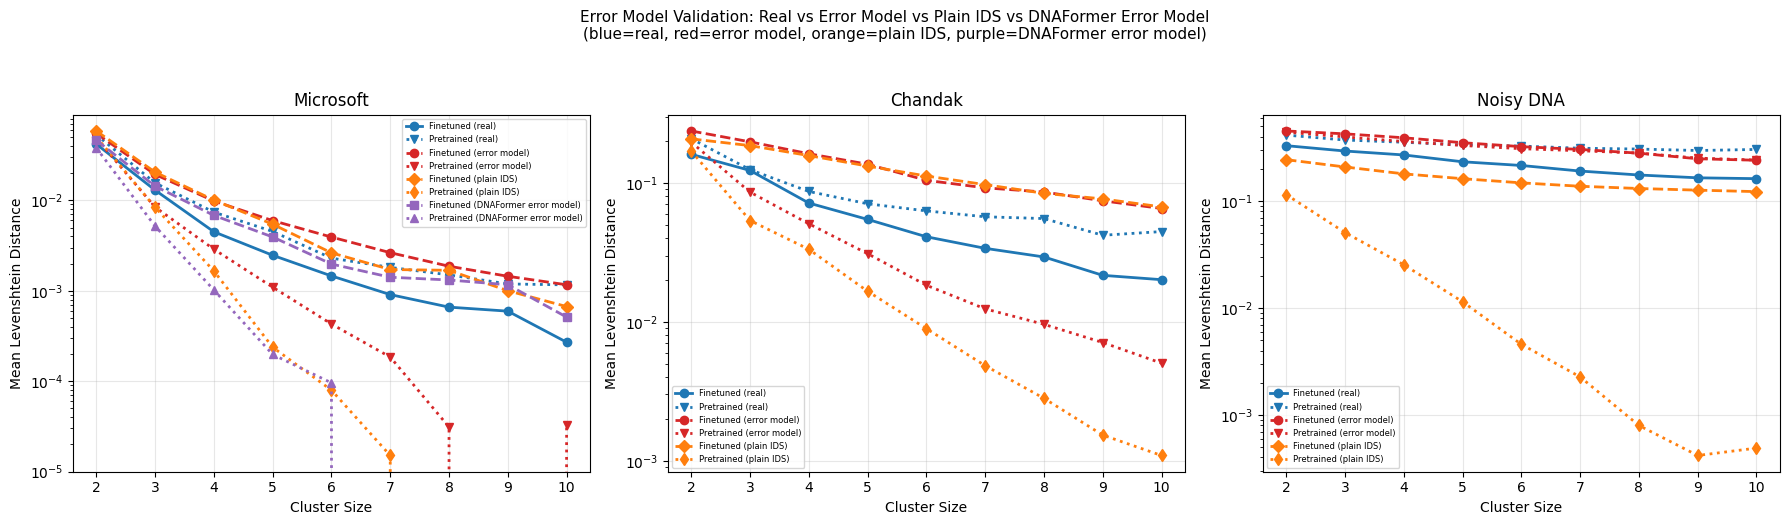

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_config = [
    ('Microsoft', 'microsoft'),
    ('Chandak', 'chandak'),
    ('Noisy DNA', 'noisy_dna'),
]

line_styles = {
    # (data_type, model_type): (color, linestyle, marker, label)
    ('real', 'finetuned'):              ('tab:blue',   '-',  'o', 'Finetuned (real)'),
    ('real', 'pretrained'):             ('tab:blue',   ':',  'v', 'Pretrained (real)'),
    ('errmodel', 'finetuned'):          ('tab:red',    '--', 'o', 'Finetuned (error model)'),
    ('errmodel', 'pretrained'):         ('tab:red',    ':',  'v', 'Pretrained (error model)'),
    ('plain_ids', 'finetuned'):         ('tab:orange', '--', 'D', 'Finetuned (plain IDS)'),
    ('plain_ids', 'pretrained'):        ('tab:orange', ':',  'd', 'Pretrained (plain IDS)'),
    ('dnaformer_errmodel', 'finetuned'):('tab:purple', '--', 's', 'Finetuned (DNAFormer error model)'),
    ('dnaformer_errmodel', 'pretrained'):('tab:purple',':',  '^', 'Pretrained (DNAFormer error model)'),
}

for ax_idx, (title, ds_name) in enumerate(plot_config):
    ax = axes[ax_idx]
    ds_exps = [e for e in experiments if e['dataset'] == ds_name]

    for exp in ds_exps:
        if exp['name'] not in all_results:
            continue
        results = all_results[exp['name']]
        data_type = exp['data_type']
        model_type = 'finetuned' if 'finetuned' in exp['name'] else 'pretrained'
        color, ls, mk, label = line_styles[(data_type, model_type)]

        by_cs = defaultdict(list)
        for r in results:
            by_cs[r['cluster_size']].append(r['levenshtein'])
        sizes = sorted(by_cs.keys())
        means = [np.mean(by_cs[s]) for s in sizes]
        ax.plot(sizes, means, marker=mk, linestyle=ls, color=color,
                linewidth=2, markersize=6, label=label)

    ax.set_xlabel('Cluster Size')
    ax.set_yscale('log')
    ax.set_ylabel('Mean Levenshtein Distance')
    ax.set_title(title)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

plt.suptitle('Error Model Validation: Real vs Error Model vs Plain IDS vs DNAFormer Error Model\n'
             '(blue=real, red=error model, orange=plain IDS, purple=DNAFormer error model)',
             fontsize=11, y=1.04)
plt.tight_layout()
plt.savefig(results_dir / 'test_error_model.png', bbox_inches='tight', dpi=150)
print('Saved to results/test_error_model.png')
plt.show()

In [6]:
# Summary table
print(f"{'Experiment':<45} {'Mean Lev':<12} {'Failure %':<12}")
print('-' * 70)
for ds_name in ['microsoft', 'chandak', 'noisy_dna']:
    ds_exps = [e for e in experiments if e['dataset'] == ds_name]
    print(f"\n  {ds_name.replace('_', ' ').title()}:")
    for exp in ds_exps:
        if exp['name'] not in all_results:
            print(f"    {exp['name']:<43} (not run)")
            continue
        lev = [r['levenshtein'] for r in all_results[exp['name']]]
        fail = 100 * sum(l > 0 for l in lev) / len(lev)
        print(f"    {exp['name']:<43} {np.mean(lev):<12.4f} {fail:<12.1f}")

Experiment                                    Mean Lev     Failure %   
----------------------------------------------------------------------

  Microsoft:
    Microsoft finetuned on real                 0.0107       29.6        
    Microsoft pretrained on real                0.0141       38.1        
    Microsoft finetuned on errmodel             0.0115       35.5        
    Microsoft pretrained on errmodel            0.0071       19.5        
    Microsoft finetuned on plainIDS             0.0117       33.8        
    Microsoft pretrained on plainIDS            0.0071       18.4        
    Microsoft finetuned on DNAFormer errmodel   0.0089       28.7        
    Microsoft pretrained on DNAFormer errmodel  0.0051       15.1        

  Chandak:
    Chandak finetuned on real                   0.0687       66.0        
    Chandak pretrained on real                  0.0912       90.6        
    Chandak finetuned on errmodel               0.1274       97.7        
    Chandak pretr